# Run all notebooks in the project

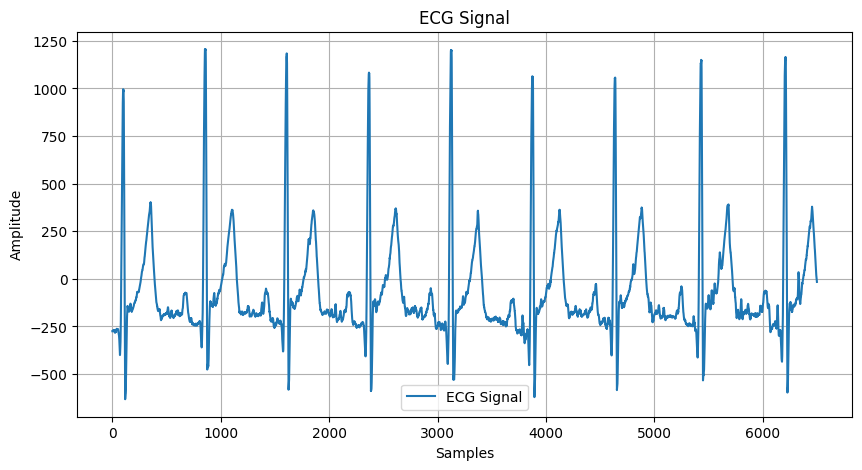

In [ ]:
#create a plot of the ECG signal with chatgpt code because of changing computer
import pandas as pd
import matplotlib.pyplot as plt

imput_file="data/ECGu.txt"


# Charger le fichier avec séparateur tabulation
ecg = pd.read_csv(
    "C:/Users/Anaëlle/Desktop/M2/MAM2ADMM/Python-Series-01/Series01-Python/data/ECGu.txt",
    sep="\t",
    header=None
)

# Créer un axe des échantillons
samples = range(len(ecg))

# Tracer le signal (par ex. la 1ère colonne)
plt.figure(figsize=(10, 5))
plt.plot(samples, ecg[0], label="ECG Signal")

# Titres et labels
plt.title("ECG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
#import data with the new computer
import pandas as pd

df = pd.read_csv("/home/anaelleakakpovi6/MAM2ADMM/Python-Series-01/Series01-Python/data/ECGu.txt")
print(df.head())

# load the libraries
import numpy as np
import matplotlib.pyplot as plt

# load the data
ecg_raw = np.loadtxt("data/ECGu.txt")
print(ecg_raw.shape)
print(ecg_raw)

   -275.0\t -119.0\t -119.0\t 
0  -275.0\t -119.0\t -119.0\t 
1  -275.0\t -118.0\t -121.0\t 
2  -275.0\t -121.0\t -112.0\t 
3  -273.0\t -120.0\t -105.0\t 
4  -274.0\t -124.0\t -101.0\t 
(6500, 3)
[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]


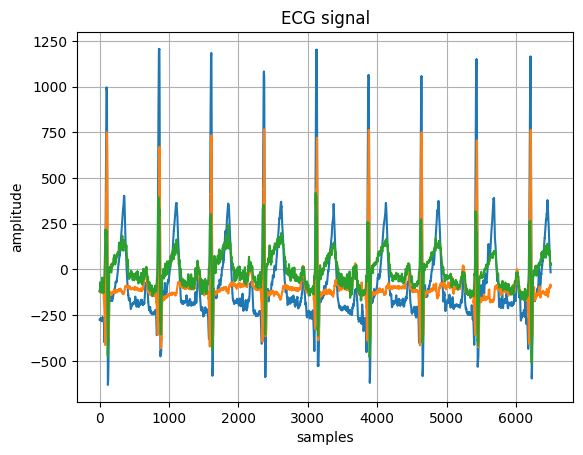

In [2]:
# plot the data
plt.plot(ecg_raw)
plt.title("ECG signal")
plt.xlabel("samples")
plt.ylabel("amplitude")
plt.grid()
plt.show()

(6500,)
[0.000e+00 1.000e-03 2.000e-03 ... 6.497e+00 6.498e+00 6.499e+00]


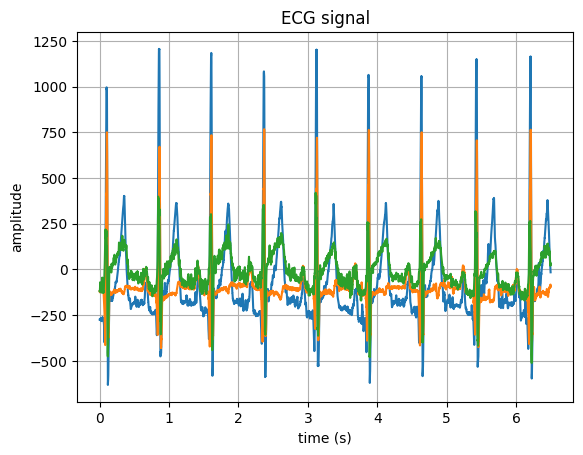

In [4]:
#create t the time vector in second
sampling_frequency=1000
T=1/sampling_frequency
N=len(ecg_raw)
start= 0
Stop= (N-1)*T
t=np.linspace(start,Stop,N)
print(t.shape)
print(t)

# plot the data with time vector
plt.plot(t, ecg_raw)
plt.title("ECG signal")
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.grid()
plt.show()



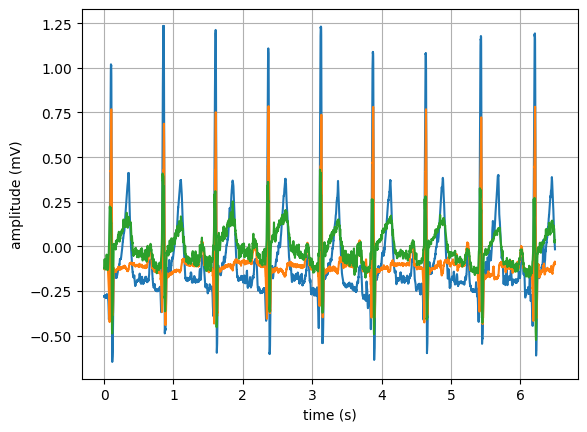

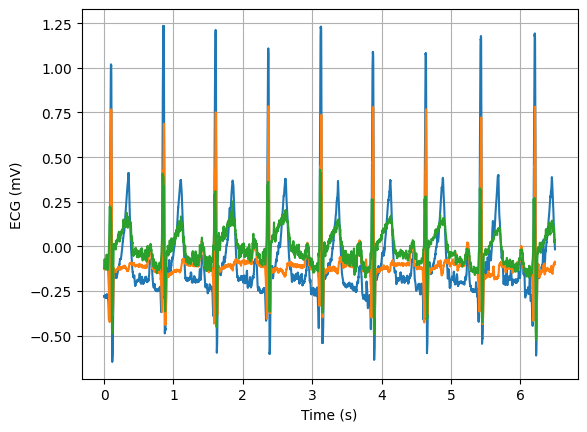

In [ ]:
# rescale the ecg signal to mV knowing that 1 unit = 1024 microV
ecg = ecg_raw * 1024 * 1e-6  # in mV - A/D converter gain : 1024 µV per unit

# plot the ecg as a function of time
plt.plot(t, ecg)
plt.xlabel("time (s)")
plt.ylabel("amplitude (mV)")
plt.grid()
# plt.title("ECG signal")
plt.show()


#compare with my own code to see mistakes 
plt.plot(t,ecg)
plt.xlabel('Time (s)')
plt.ylabel('ECG (mV)')
plt.grid()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (6500,) and (3,)

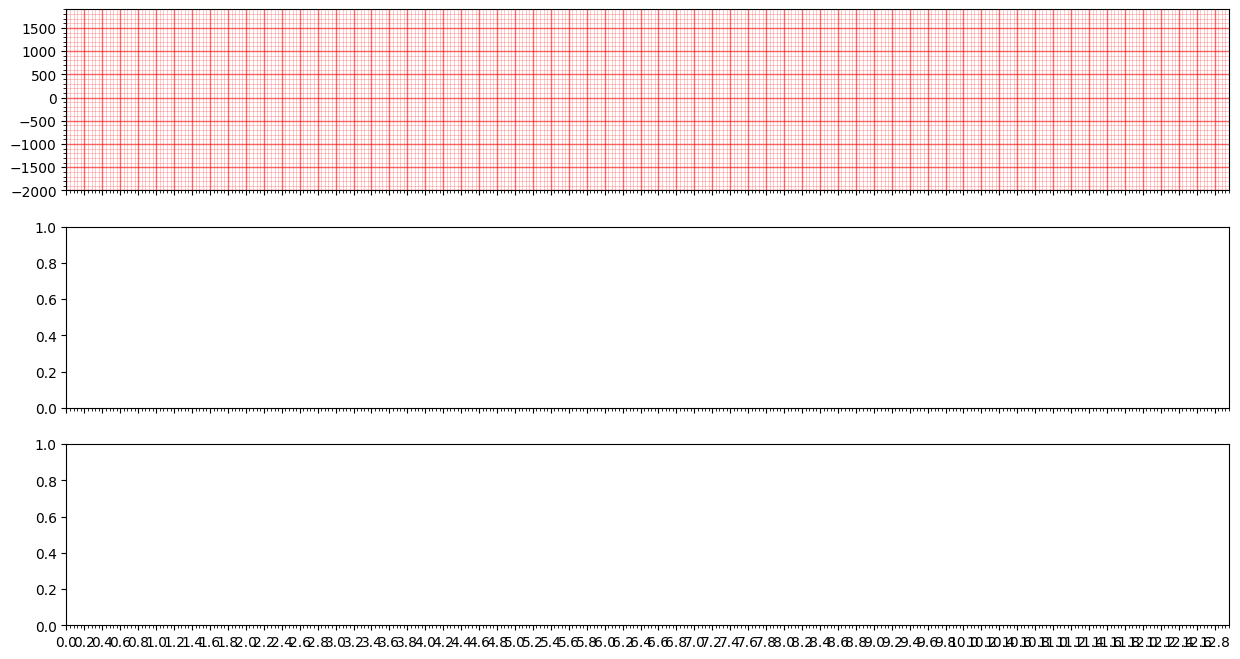

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================
# 2. Créer l’axe temporel
# ============================

fs = 500  # fréquence d'échantillonnage (Hz) — à adapter si nécessaire
time = np.arange(len(ecg)) / fs  # axe en secondes

# ============================
# 3. Tracé ECG réaliste
# ============================

fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

# Paramètres de la grille ECG
small_grid = 0.04   # 40 ms
large_grid = 0.2    # 200 ms
amp_small = 0.1     # 0.1 mV
amp_large = 0.5     # 0.5 mV

for i, ax in enumerate(axes):
    # Grille fine (petits carreaux)
    ax.set_xticks(np.arange(0, max(time), small_grid), minor=True)
    ax.set_yticks(np.arange(-2000, 2000, amp_small * 1000), minor=True)

    # Grille large (grands carreaux)
    ax.set_xticks(np.arange(0, max(time), large_grid))
    ax.set_yticks(np.arange(-2000, 2000, amp_large * 1000))

    # Style de la grille ECG
    ax.grid(which="minor", color="red", linewidth=0.5, alpha=0.3)
    ax.grid(which="major", color="red", linewidth=1, alpha=0.6)

    # Tracer la dérivation
    ax.plot(time, ecg[i], color="black", linewidth=1)
    ax.set_title(f"ECG Lead {i+1}", loc="left")

    # Plage verticale réaliste (à ajuster selon ton signal)
    ax.set_ylim(-1500, 1500)

# Labels partagés
axes[-1].set_xlabel("Temps (s)")
fig.suptitle("Tracé ECG multicanal avec grille médicale", fontsize=16)

plt.tight_layout()
plt.show()


In [ ]:
# ajout d'un texte juste pour voir si ça marche sur github